#Import libraries



In [123]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc

#Load data & create copy

In [124]:
data = pd.read_csv("/content/NFL Play by Play 2009-2016 (v3).csv")
df = data.copy()


/tmp/ipython-input-2024863774.py:1: DtypeWarning: Columns (25,51) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("/content/NFL Play by Play 2009-2016 (v3).csv")


#Basic check

In [125]:
df.isnull().sum()


,0
Date,0
GameID,0
Drive,0
qtr,0
down,54218
...,...
Win_Prob,21993
WPA,4817
airWPA,220738
yacWPA,220956


# 3. Data Cleaning

In [126]:
# Fill numeric columns with median (SAFE WAY)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical & boolean columns with mode (SAFE WAY)
cat_cols = df.select_dtypes(include=['object', 'bool']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


#Select useful columns (IMPORTANT)

In [127]:
# Drop duplicates
df.drop_duplicates(inplace=True)

# Drop columns that won't help prediction
irrelevant_cols = ['game_id', 'play_id', 'time', 'season']  # example
df.drop(columns=[col for col in irrelevant_cols if col in df.columns], inplace=True)


In [128]:
df.columns.tolist()


['Date',
 'GameID',
 'Drive',
 'qtr',
 'down',
 'TimeUnder',
 'TimeSecs',
 'PlayTimeDiff',
 'SideofField',
 'yrdln',
 'yrdline100',
 'ydstogo',
 'ydsnet',
 'GoalToGo',
 'FirstDown',
 'posteam',
 'DefensiveTeam',
 'desc',
 'PlayAttempted',
 'Yards.Gained',
 'sp',
 'Touchdown',
 'ExPointResult',
 'TwoPointConv',
 'DefTwoPoint',
 'Safety',
 'Onsidekick',
 'PuntResult',
 'PlayType',
 'Passer',
 'Passer_ID',
 'PassAttempt',
 'PassOutcome',
 'PassLength',
 'AirYards',
 'YardsAfterCatch',
 'QBHit',
 'PassLocation',
 'InterceptionThrown',
 'Interceptor',
 'Rusher',
 'Rusher_ID',
 'RushAttempt',
 'RunLocation',
 'RunGap',
 'Receiver',
 'Receiver_ID',
 'Reception',
 'ReturnResult',
 'Returner',
 'BlockingPlayer',
 'Tackler1',
 'Tackler2',
 'FieldGoalResult',
 'FieldGoalDistance',
 'Fumble',
 'RecFumbTeam',
 'RecFumbPlayer',
 'Sack',
 'Challenge.Replay',
 'ChalReplayResult',
 'Accepted.Penalty',
 'PenalizedTeam',
 'PenaltyType',
 'PenalizedPlayer',
 'Penalty.Yards',
 'PosTeamScore',
 'DefTeamScor

In [129]:
num_cols = ['down', 'ydstogo', 'yrdline100', 'Yards.Gained', 'AirYards']
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)


/tmp/ipython-input-2898189671.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [130]:
bool_like = ['GoalToGo', 'PassAttempt', 'RushAttempt']
for col in bool_like:
    df[col] = df[col].astype(int)


In [131]:
target = 'Touchdown'


In [132]:
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print("Categorical columns to encode:", cat_cols)


Categorical columns to encode: ['Date', 'SideofField', 'posteam', 'DefensiveTeam', 'desc', 'ExPointResult', 'TwoPointConv', 'DefTwoPoint', 'PuntResult', 'PlayType', 'Passer', 'Passer_ID', 'PassOutcome', 'PassLength', 'PassLocation', 'Interceptor', 'Rusher', 'Rusher_ID', 'RunLocation', 'RunGap', 'Receiver', 'Receiver_ID', 'ReturnResult', 'Returner', 'BlockingPlayer', 'Tackler1', 'Tackler2', 'FieldGoalResult', 'RecFumbTeam', 'RecFumbPlayer', 'ChalReplayResult', 'PenalizedTeam', 'PenaltyType', 'PenalizedPlayer', 'HomeTeam', 'AwayTeam', 'Timeout_Team']


In [133]:
df.drop_duplicates(inplace=True)


In [134]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object', 'bool']).columns

In [135]:
df[col] = df[col].fillna(df[col].mode()[0])


In [136]:
# Numeric columns -> median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


In [137]:
if 'yards_gained' in df.columns:
    df = df[(df['yards_gained'] >= -10) & (df['yards_gained'] <= 99)]


In [138]:
# Outlier removal (correct column names)
df = df[(df['Yards.Gained'] >= -10) & (df['Yards.Gained'] <= 99)]
df = df[(df['yrdline100'] >= 1) & (df['yrdline100'] <= 100)]
df = df[df['ydstogo'] <= 50]

In [139]:
# 7️⃣ Feature Engineering
df['crucial_down'] = df['down'].apply(lambda x: 1 if x in [3,4] else 0)


In [140]:
df.rename(columns={
    'yrdline100': 'yardline_100',
    'Yards.Gained': 'yards_gained',
    'Touchdown': 'touchdown',
    'PassAttempt': 'pass_attempt',
    'RushAttempt': 'rush_attempt',
    'AirYards': 'air_yards'
}, inplace=True)


In [141]:
print(df.columns)
print(df.isnull().sum())
print(df['touchdown'].value_counts())


Index(['Date', 'GameID', 'Drive', 'qtr', 'down', 'TimeUnder', 'TimeSecs',
       'PlayTimeDiff', 'SideofField', 'yrdln',
       ...
       'Home_WP_pre', 'Away_WP_pre', 'Home_WP_post', 'Away_WP_post',
       'Win_Prob', 'WPA', 'airWPA', 'yacWPA', 'Season', 'crucial_down'],
      dtype='object', length=102)
Date            0
GameID          0
Drive           0
qtr             0
down            0
               ..
WPA             0
airWPA          0
yacWPA          0
Season          0
crucial_down    0
Length: 102, dtype: int64
touchdown
0    350979
1     10555
Name: count, dtype: int64


In [142]:
print(df['touchdown'].value_counts(normalize=True))


touchdown
0    0.970805
1    0.029195
Name: proportion, dtype: float64


In [143]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]


In [144]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [145]:
X_train.dtypes

,0
Date,object
GameID,int64
Drive,int64
qtr,int64
down,float64
...,...
Win_Prob,float64
WPA,float64
airWPA,float64
yacWPA,float64


#Train the model

In [146]:
# Target
y = df['touchdown']

# Features – keep ONLY numeric columns
X = df.drop(columns=['touchdown'])
X = X.select_dtypes(include=['int64', 'float64'])


In [147]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [148]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())


In [149]:
X = df.drop(columns=['touchdown'])
X = X.select_dtypes(include=['int64', 'float64'])

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')

X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)


In [150]:

df[num_cols] = df[num_cols].fillna(df[num_cols].median())


In [151]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [152]:
np.unique(y_train, return_counts=True)


(array([0, 1]), array([280783,   8444]))

#Model evaluation

In [153]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [154]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.5441935082357171

Confusion Matrix:
 [[38299 31897]
 [ 1061  1050]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.55      0.70     70196
           1       0.03      0.50      0.06      2111

    accuracy                           0.54     72307
   macro avg       0.50      0.52      0.38     72307
weighted avg       0.95      0.54      0.68     72307



In [155]:
df.columns.tolist()

['Date',
 'GameID',
 'Drive',
 'qtr',
 'down',
 'TimeUnder',
 'TimeSecs',
 'PlayTimeDiff',
 'SideofField',
 'yrdln',
 'yardline_100',
 'ydstogo',
 'ydsnet',
 'GoalToGo',
 'FirstDown',
 'posteam',
 'DefensiveTeam',
 'desc',
 'PlayAttempted',
 'yards_gained',
 'sp',
 'touchdown',
 'ExPointResult',
 'TwoPointConv',
 'DefTwoPoint',
 'Safety',
 'Onsidekick',
 'PuntResult',
 'PlayType',
 'Passer',
 'Passer_ID',
 'pass_attempt',
 'PassOutcome',
 'PassLength',
 'air_yards',
 'YardsAfterCatch',
 'QBHit',
 'PassLocation',
 'InterceptionThrown',
 'Interceptor',
 'Rusher',
 'Rusher_ID',
 'rush_attempt',
 'RunLocation',
 'RunGap',
 'Receiver',
 'Receiver_ID',
 'Reception',
 'ReturnResult',
 'Returner',
 'BlockingPlayer',
 'Tackler1',
 'Tackler2',
 'FieldGoalResult',
 'FieldGoalDistance',
 'Fumble',
 'RecFumbTeam',
 'RecFumbPlayer',
 'Sack',
 'Challenge.Replay',
 'ChalReplayResult',
 'Accepted.Penalty',
 'PenalizedTeam',
 'PenaltyType',
 'PenalizedPlayer',
 'Penalty.Yards',
 'PosTeamScore',
 'DefTea

In [156]:
#Yards remaining for touchdown
df['score_diff_posteam'] = df['PosTeamScore'] - df['DefTeamScore']


In [157]:
#Goal-to-go flag:

df['goal_to_go_flag'] = df['GoalToGo'].apply(lambda x: 1 if x==1 else 0)

In [158]:
#Quarter phase (for one-hot encoding):

def quarter_phase(qtr):
    if qtr in [1, 2]:
        return 'first_half'
    elif qtr in [3, 4]:
        return 'second_half'
    else:
        return 'overtime'

df['quarter_phase'] = df['qtr'].apply(quarter_phase)

#Encoding part

In [159]:
df['time_remaining_sec'] = df['TimeUnder']*60 + df['TimeSecs']

In [160]:
from sklearn.preprocessing import LabelEncoder

label_cols = ['posteam','DefensiveTeam','Passer','Rusher','Receiver','HomeTeam','AwayTeam']
le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col].astype(str))


In [161]:
feature_cols = [
    'down', 'ydstogo', 'yardline_100', 'yards_remaining',
    'score_diff_posteam', 'goal_to_go_flag', 'is_pass', 'is_rush',
    'time_remaining_sec'
] + [col for col in df.columns if any(prefix in col for prefix in [
    'SideofField_', 'quarter_phase_', 'PlayType_', 'PassLocation_', 'RunLocation_', 'RunGap_'
])] + label_cols


#Model Evaluation

Accuracy: 0.5441935082357171

Confusion Matrix:
 [[38299 31897]
 [ 1061  1050]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.55      0.70     70196
           1       0.03      0.50      0.06      2111

    accuracy                           0.54     72307
   macro avg       0.50      0.52      0.38     72307
weighted avg       0.95      0.54      0.68     72307



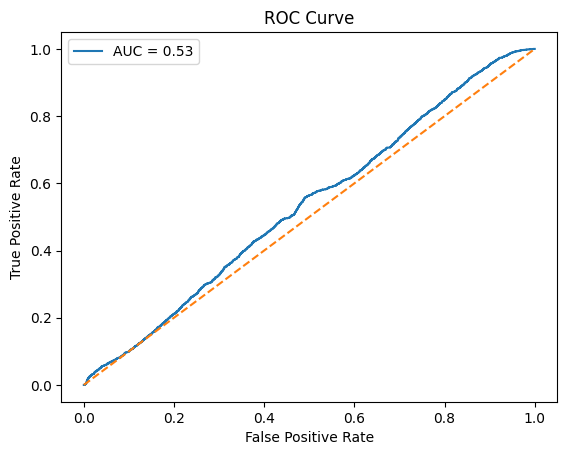

In [163]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # probability of touchdown

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [164]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(class_weight='balanced', n_estimators=500, random_state=42)


In [165]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)


#Feature Importance

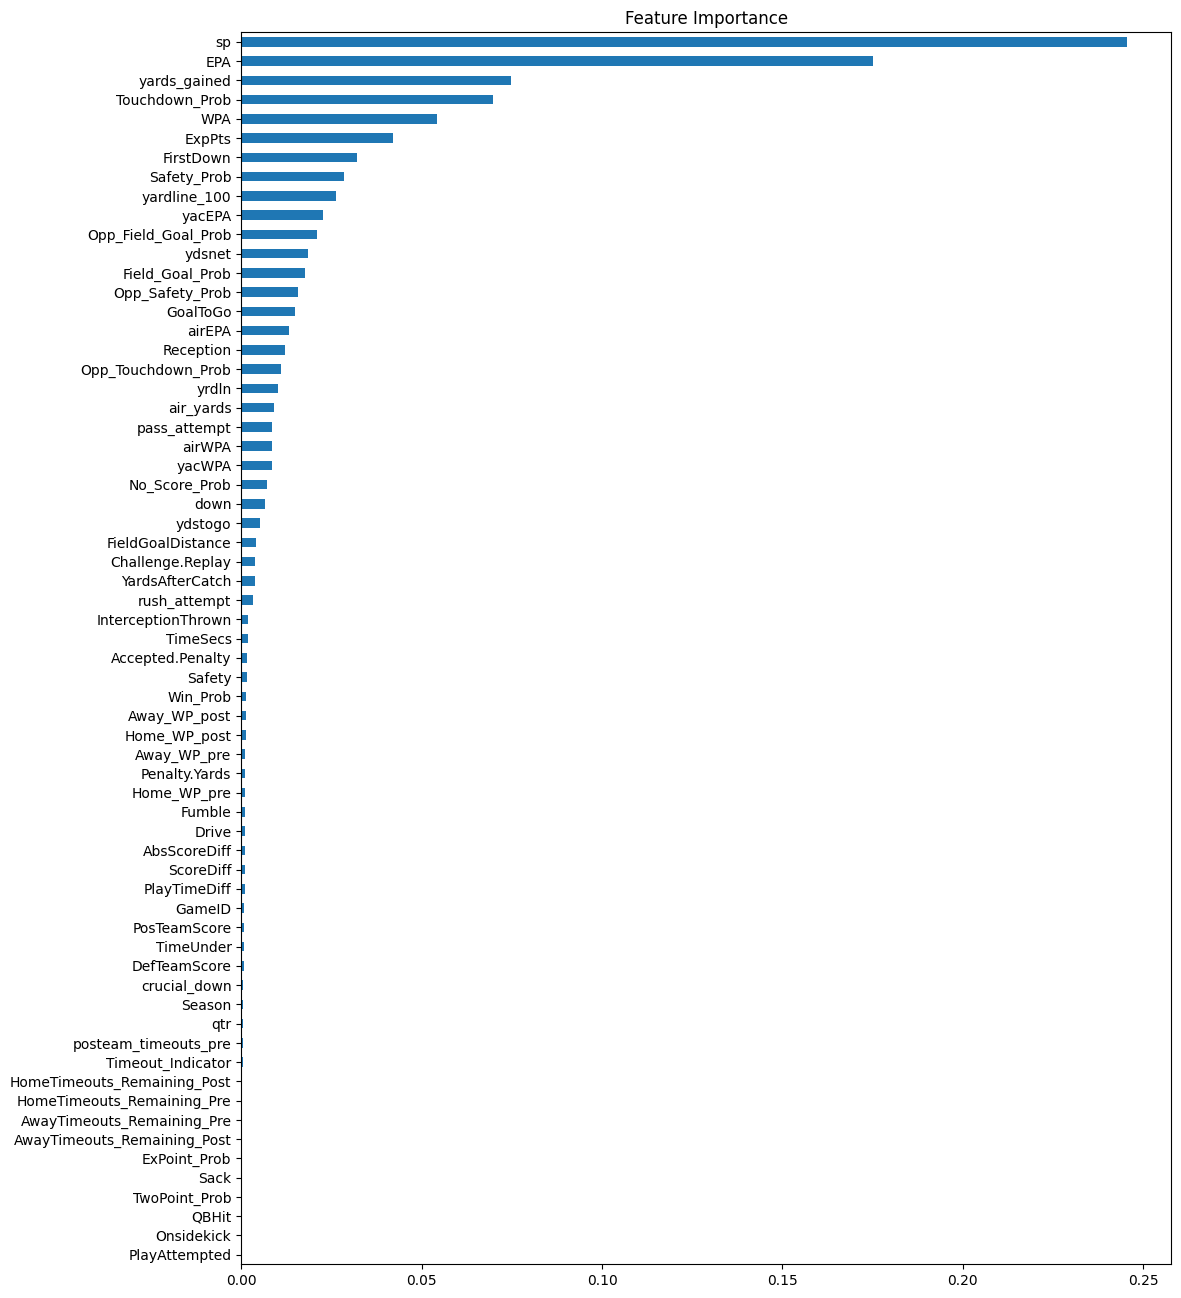

In [171]:
from sklearn.ensemble import RandomForestClassifier

# 1️⃣ Initialize
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2️⃣ Fit on training data
model.fit(X_train, y_train)  # Make sure X_train and y_train are ready

# 3️⃣ Get feature importances
importance = pd.Series(model.feature_importances_, index=X_train.columns).sort_values()

# 4️⃣ Plot
importance.plot(kind='barh', figsize=(12,16), title="Feature Importance")
plt.show()


#Save Model and Features

In [174]:


df.to_csv("nfl_cleaned.csv", index=False)

print("✅ Model and features saved successfully!")


✅ Model and features saved successfully!


#Correlation Heatmap

In [179]:
df.columns.tolist()

['Date',
 'GameID',
 'Drive',
 'qtr',
 'down',
 'TimeUnder',
 'TimeSecs',
 'PlayTimeDiff',
 'SideofField',
 'yrdln',
 'yardline_100',
 'ydstogo',
 'ydsnet',
 'GoalToGo',
 'FirstDown',
 'posteam',
 'DefensiveTeam',
 'desc',
 'PlayAttempted',
 'yards_gained',
 'sp',
 'touchdown',
 'ExPointResult',
 'TwoPointConv',
 'DefTwoPoint',
 'Safety',
 'Onsidekick',
 'PuntResult',
 'PlayType',
 'Passer',
 'Passer_ID',
 'pass_attempt',
 'PassOutcome',
 'PassLength',
 'air_yards',
 'YardsAfterCatch',
 'QBHit',
 'PassLocation',
 'InterceptionThrown',
 'Interceptor',
 'Rusher',
 'Rusher_ID',
 'rush_attempt',
 'RunLocation',
 'RunGap',
 'Receiver',
 'Receiver_ID',
 'Reception',
 'ReturnResult',
 'Returner',
 'BlockingPlayer',
 'Tackler1',
 'Tackler2',
 'FieldGoalResult',
 'FieldGoalDistance',
 'Fumble',
 'RecFumbTeam',
 'RecFumbPlayer',
 'Sack',
 'Challenge.Replay',
 'ChalReplayResult',
 'Accepted.Penalty',
 'PenalizedTeam',
 'PenaltyType',
 'PenalizedPlayer',
 'Penalty.Yards',
 'PosTeamScore',
 'DefTea

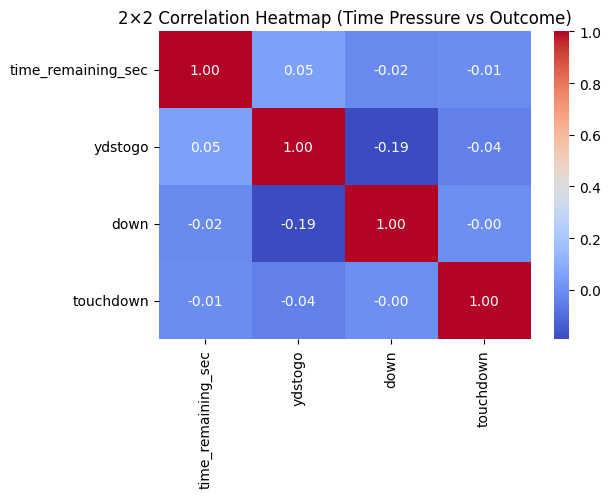

In [180]:
corr_features = ['time_remaining_sec', 'ydstogo', 'down', 'touchdown']

corr_matrix = df[corr_features].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("2×2 Correlation Heatmap (Time Pressure vs Outcome)")
plt.show()


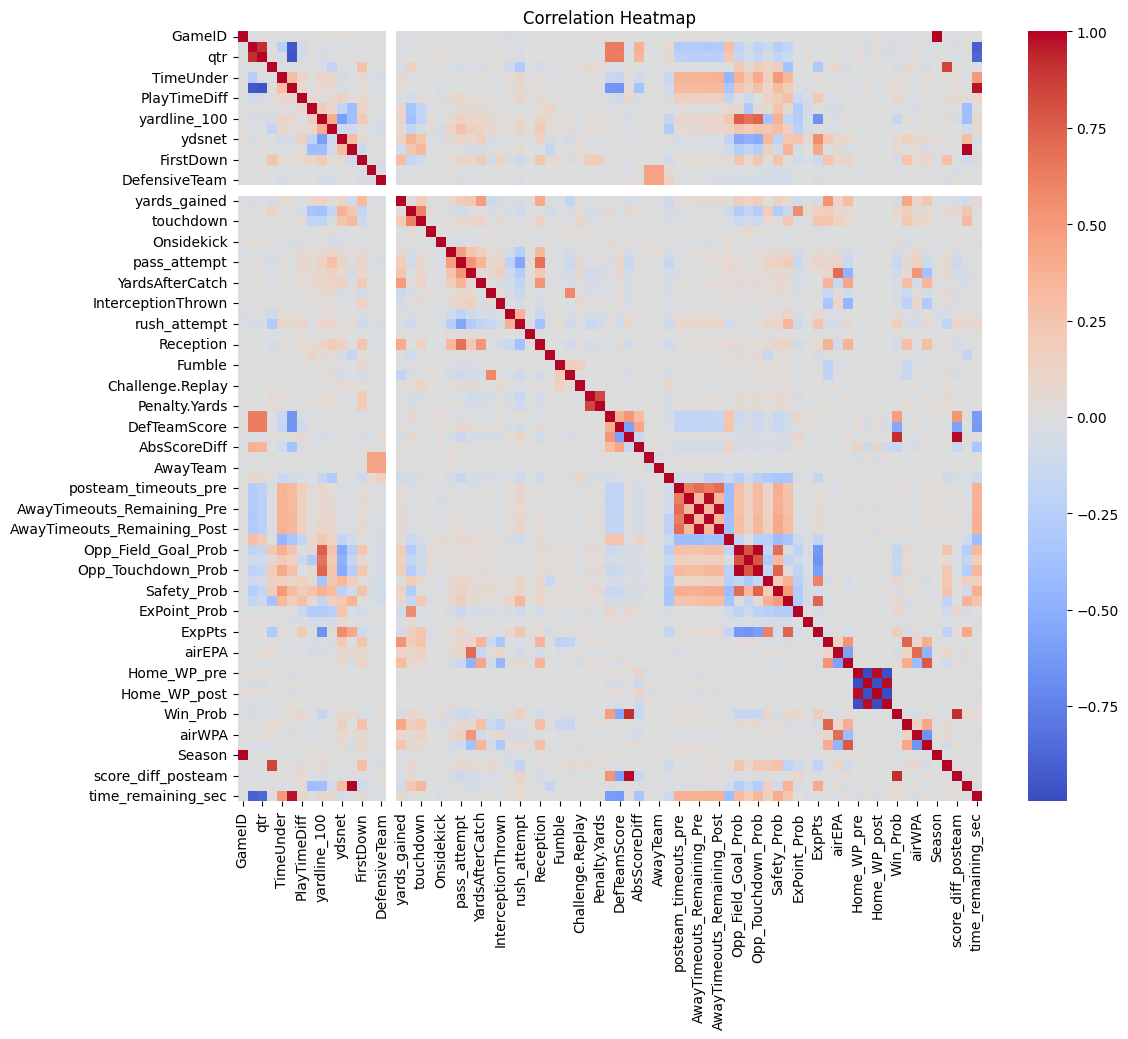

In [182]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,10))
sns.heatmap(numeric_cols.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap_2x2.png", bbox_inches='tight')
plt.show()


In [183]:
corr_target = numeric_cols.corr()['touchdown'].sort_values(ascending=False)
print(corr_target)


touchdown              1.000000
sp                     0.606101
goal_to_go_flag        0.322177
GoalToGo               0.322177
EPA                    0.249605
                         ...   
Opp_Touchdown_Prob    -0.126552
Opp_Field_Goal_Prob   -0.128985
yrdln                 -0.184753
yardline_100          -0.198209
PlayAttempted               NaN
Name: touchdown, Length: 75, dtype: float64


#Target Distribution

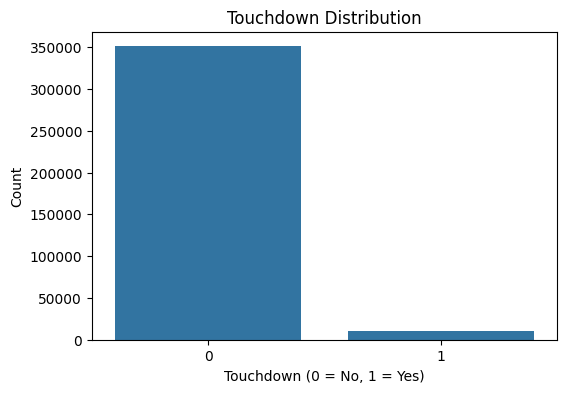

In [184]:
plt.figure(figsize=(6,4))
sns.countplot(x='touchdown', data=df)
plt.title("Touchdown Distribution")
plt.xlabel("Touchdown (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


#Touchdowns by Down

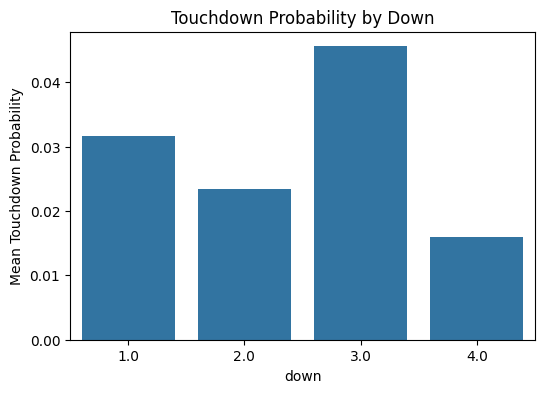

In [185]:
plt.figure(figsize=(6,4))
sns.barplot(x='down', y='touchdown', data=df.groupby('down')['touchdown'].mean().reset_index())
plt.title("Touchdown Probability by Down")
plt.ylabel("Mean Touchdown Probability")
plt.show()


#Yards to Go vs Touchdowns

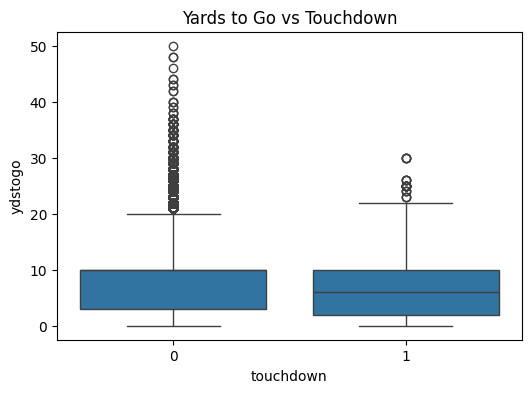

In [186]:
plt.figure(figsize=(6,4))
sns.boxplot(x='touchdown', y='ydstogo', data=df)
plt.title("Yards to Go vs Touchdown")
plt.show()


#Touchdowns by Quarter Phase

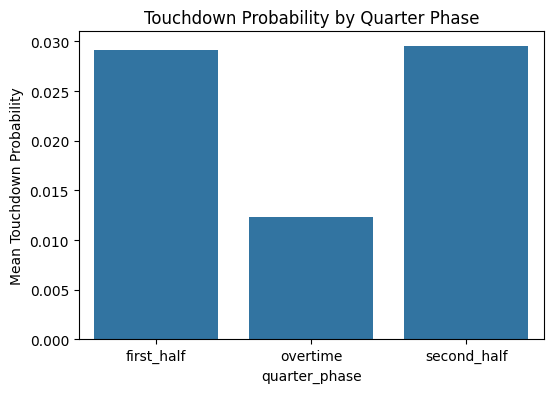

In [187]:
plt.figure(figsize=(6,4))
sns.barplot(x='quarter_phase', y='touchdown', data=df.groupby('quarter_phase')['touchdown'].mean().reset_index())
plt.title("Touchdown Probability by Quarter Phase")
plt.ylabel("Mean Touchdown Probability")
plt.show()


#Pass vs Rush Success Rate


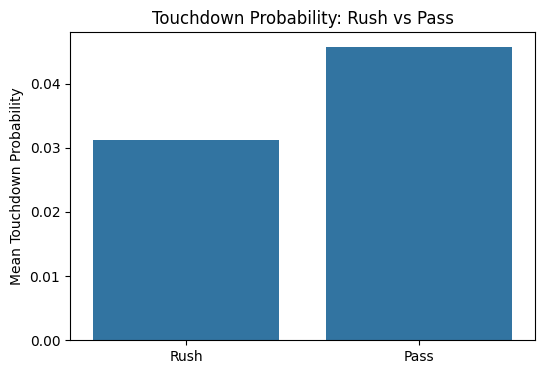

In [189]:
rush_td = df[df['rush_attempt'] == 1]['touchdown'].mean()
pass_td = df[df['pass_attempt'] == 1]['touchdown'].mean()

plt.figure(figsize=(6,4))
sns.barplot(
    x=['Rush', 'Pass'],
    y=[rush_td, pass_td]
)
plt.title("Touchdown Probability: Rush vs Pass")
plt.ylabel("Mean Touchdown Probability")
plt.show()


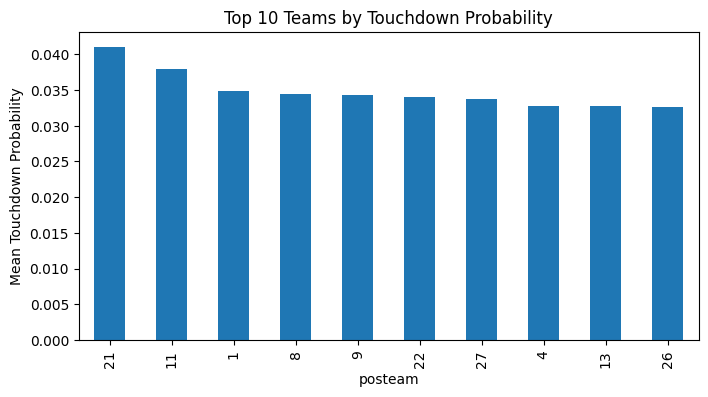

In [191]:
top_teams = df.groupby('posteam')['touchdown'].mean().sort_values(ascending=False).head(10)
top_teams.plot(kind='bar', figsize=(8,4), title="Top 10 Teams by Touchdown Probability")
plt.ylabel("Mean Touchdown Probability")
plt.savefig("Mean Touchdown Probability.png", bbox_inches='tight')

plt.show()
